--- **Progetto IAS** ---

Riconoscimento audio DeepFake testando il modello shallow SVM estraendo gli MFCC.

* Marco Caruso (60/79/00107)
* Mauro Contu (60/79/00115)
* Marco Niccolò Loddo (60/79/00097)


##Descrizione dell'agente e dell'ambiente


###🌍 Ambiente


L'ambiente in cui l'agente opera è costituito dall’insieme dei segnali audio digitali in inglese. Il dataset in questione (FakeAVCeleb) è bilanciato ed è composto da 200 audio, suddivisi in: 50 audio real maschili, 50 audio fake maschili, 50 audio real femminili e 50 audio fake femminili. Gli audio fake sono stati creati a partire da quelli real.
Questo dataset è formato da audio in formato .mp3.

Questi file vocali, oltre che variare in termini di parlante (uomo/donna), variano anche in termini di intonazione, durata (da 3 a 15 secondi circa) e qualità dell'audio.

L'ambiente in questione è:
* ***Parzialmente osservabile***: abbiamo accesso agli audio forniti e alle loro caratteristiche estratte, ma non conosce esattamente la fonte o il contesto reale dell’audio.
* ***Stocastico***: gli input audio possono variare molto, contenere rumore o artefatti, e il comportamento del modello può non essere sempre deterministico a causa della complessità del segnale e del modello stesso.
* ***Statico***: ogni audio viene analizzato singolarmente e il sistema non deve interagire con un ambiente in evoluzione nel tempo o che cambia in modo dinamico durante la classificazione.
* ***Discreto***: in termini di azioni il modello prende una decisione binaria (real vs fake) per ogni singolo input audio.

###👤 Agente


L'agente in questione è un sistema di classificazione automatica strutturato per distinguere tra audio vocali reali e deepfake, ovvero audio sintetici/manipolati presenti nell'ambiente descritto precedentemente. Questa classificazione si basa su caratteristiche acustiche estratte dai segnali. I passi che segue l'agente per effettuare questa classificazione sono:

1. ***Preprocessing dell'audio***: gli audio mp3 vengono campionati a una frequenza predefinita, si normalizza il volume di ogni audio e si taglia il silenzio lungo la coda dell'audio (ove presente) utilizzando la feature Energy. Effettuiamo quest'ultima operazione perché dallo studio del dataset, è emerso che la maggior parte degli audio fake presenta appunto un silenzio finale, che può influenzare la direzione della classificazione.

2. ***Estrazione delle feature***: da ogni segnale pre-processato vengono estratti i Mel Frequency Cepstral Coefficients (MFCC) con i corrispettivi delta e delta^2 (per avere informazioni riguardanti la variazione), e poi calcoliamo la media e la deviazione standard per ogni set di feature.

 - Delta: cattura la velocità del cambiamento acustico. È utile per riconoscere transizioni nei fonemi.
 - Delta^2: misura l’accelerazione del cambiamento. Fornisce un'indicazione della curvatura nel segnale vocale.

3. ***Modello di classificazione***: viene utilizzato un classificatore supervisionato, ovvero l'SVM (Support Vector Machine) con un kernel non lineare RBF, dove si esegue anche un tuning degli iperparametri C (margine di penalizzazione) e gamma (larghezza del kernel).

4. ***Addestramento e valutazione***: utilizziamo GridSearchCV con 5-fold cross-validation sul training set per trovare la miglior combinazione di iperparametri, per poi testare il modello ottimizzato sul test-set non ancora visto.





***Schema riassuntivo***

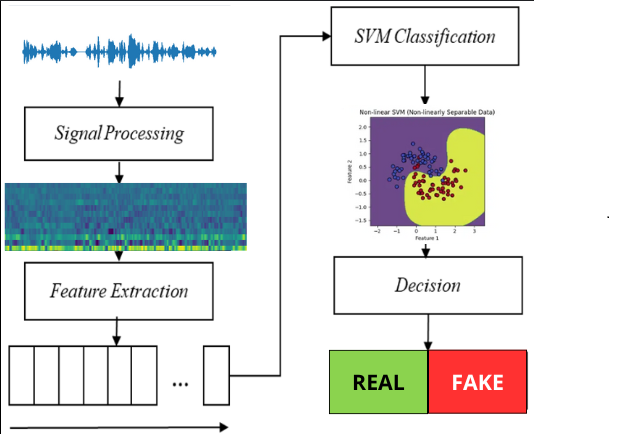

##Installazione del dataset



-Scarichiamo il dataset utilizzando l'ID: 1AKLJoi31Jlk7gJMmqKtnePhdwExD38-c.


In [ ]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
downloaded = drive.CreateFile({'id': '1AKLJoi31Jlk7gJMmqKtnePhdwExD38-c'})

In [ ]:
downloaded.GetContentFile('deepfakes_db.zip')

In [ ]:
!unzip deepfakes_db.zip

Archive:  deepfakes_db.zip
   creating: FakeAVCeleb_v1.2small/
   creating: FakeAVCeleb_v1.2small/Fake/
   creating: FakeAVCeleb_v1.2small/Fake/men/
   creating: FakeAVCeleb_v1.2small/Fake/men/id00055/
  inflating: FakeAVCeleb_v1.2small/Fake/men/id00055/00120_fake.mp3  
   creating: FakeAVCeleb_v1.2small/Fake/men/id00063/
  inflating: FakeAVCeleb_v1.2small/Fake/men/id00063/00021_fake.mp3  
   creating: FakeAVCeleb_v1.2small/Fake/men/id00171/
  inflating: FakeAVCeleb_v1.2small/Fake/men/id00171/00092_fake.mp3  
   creating: FakeAVCeleb_v1.2small/Fake/men/id00183/
  inflating: FakeAVCeleb_v1.2small/Fake/men/id00183/00015_fake.mp3  
   creating: FakeAVCeleb_v1.2small/Fake/men/id00185/
  inflating: FakeAVCeleb_v1.2small/Fake/men/id00185/00015_fake.mp3  
   creating: FakeAVCeleb_v1.2small/Fake/men/id00186/
  inflating: FakeAVCeleb_v1.2small/Fake/men/id00186/00120_fake.mp3  
   creating: FakeAVCeleb_v1.2small/Fake/men/id00187/
  inflating: FakeAVCeleb_v1.2small/Fake/men/id00187/00360_fake.mp3

##Importazione pacchetti

In [ ]:
# Audio e Media
from pydub import AudioSegment # Per caricare, tagliare e salvare file audio
from IPython.display import Audio # Per riprodurre audio direttamente in notebook
import moviepy.editor as mp # Per elaborare file video

# Elaborazione audio
import librosa # Libreria principale per analisi del segnale audio
import librosa.display # Per visualizzare waveform e spettrogrammi
import numpy as np # Per operazioni matematiche e array numerici
import matplotlib.pyplot as plt # Per creare grafici statici

# Sistema operativo e gestione file
import os # Per navigare e gestire cartelle/file
import glob # Per trovare file con pattern
import shutil # Per spostare o copiare file


import random # Per generare numeri casuali

# Machine Learning
import sklearn
from sklearn.svm import SVC # Support Vector Machine per classificazione
from sklearn.pipeline import make_pipeline # Per creare pipeline ML con preprocessing + modello
from sklearn.preprocessing import StandardScaler # Normalizzazione standard (media=0, std=1)
from sklearn.model_selection import (
    train_test_split, # Dividisione dei dati in train/test
    StratifiedKFold, # k-fold mantenendo bilanciamento classi
    cross_val_score, # Valutazione modelli via cross-validation
    GridSearchCV # Cerca i migliori iperparametri con CV
    )

# Metriche di valutazione
from sklearn.metrics import (
    classification_report, # Riassunto con precision, recall, f1
    accuracy_score, # Percentuale di classificazioni corrette
    f1_score, # Media armonica tra precision e recall
    roc_curve, auc, # Per ROC curve e AUC
    confusion_matrix, # Matrice di confusione
    ConfusionMatrixDisplay, # Visualizzazione della matrice di confusione
    roc_auc_score # Calcola l'AUC per classificazione binaria
)


import seaborn as sns # Libreria grafica avanzata

!pip install plotly
import plotly.graph_objects as go # Grafici


from tqdm import tqdm  # Barra di avanzamento



##Prova funzionamento audio

Effettuiamo la prova di ascolto di due audio: uno real e uno fake

Esempio audio real

In [ ]:
audio_real_00028 ="/content/FakeAVCeleb_v1.2small/Real/men/id00963/00028.mp3"
Audio(audio_real_00028)


Esempio audio fake

In [ ]:
audio_fake_00028  ="/content/FakeAVCeleb_v1.2small/Fake/men/id00963/00028_fake.mp3"
Audio(audio_fake_00028 )

##Conteggio dei campioni del dataset

Numero totale di audio nel dataset: 200

Numero totale di audio REAL: 100

Numero totale di audio FAKE: 100



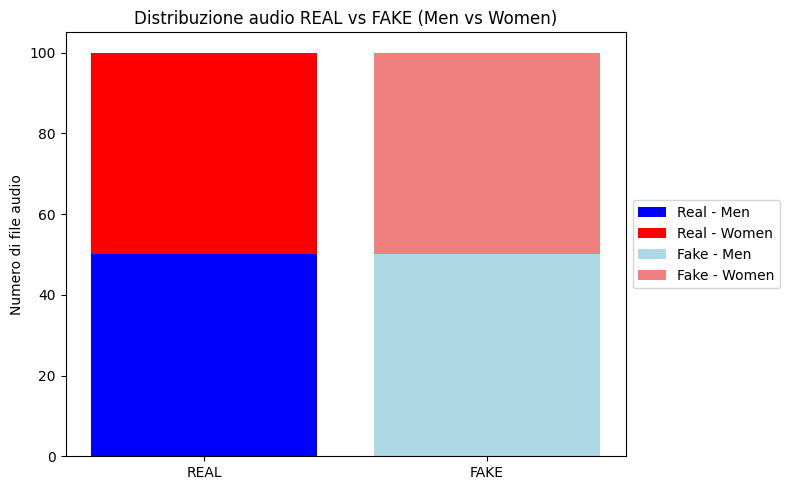

In [ ]:
def conta_file_audio(percorso_cartella, estensione=".mp3"):
    conta = 0
    for root, dirs, files in os.walk(percorso_cartella):
        for file in files:
            if file.lower().endswith(estensione):
                conta += 1
    return conta

# Percorso del dataset
dataset_path = "/content/FakeAVCeleb_v1.2small"

# Percorsi per ogni categoria
categorie = {
    "Real_men": os.path.join(dataset_path, "Real", "men"),
    "Real_women": os.path.join(dataset_path, "Real", "women"),
    "Fake_men": os.path.join(dataset_path, "Fake", "men"),
    "Fake_women": os.path.join(dataset_path, "Fake", "women"),
}

# Conta file
conteggi = {nome: conta_file_audio(path) for nome, path in categorie.items()}

# Calcolo dei totali
totale_real = conteggi["Real_men"] + conteggi["Real_women"]
totale_fake = conteggi["Fake_men"] + conteggi["Fake_women"]
totale_audio = totale_real + totale_fake

# Stampa
print(f"Numero totale di audio nel dataset: {totale_audio}\n")
print(f"Numero totale di audio REAL: {totale_real}\n")
print(f"Numero totale di audio FAKE: {totale_fake}\n")


# Estrai conteggi separati
real_men = conteggi["Real_men"]
real_women = conteggi["Real_women"]
fake_men = conteggi["Fake_men"]
fake_women = conteggi["Fake_women"]

# Prepara i dati per la bar chart impilata
labels = ["REAL", "FAKE"]
men_counts = [real_men, fake_men]
women_counts = [real_women, fake_women]

# Grafico a barre impilate
plt.figure(figsize=(8, 5))
# REAL: men (blue) + women (red)
plt.bar("REAL", real_men, label="Real - Men", color="blue")
plt.bar("REAL", real_women, bottom=real_men, label="Real - Women", color="red")

# FAKE
plt.bar("FAKE", fake_men, label="Fake - Men", color="lightblue")
plt.bar("FAKE", fake_women, bottom=fake_men, label="Fake - Women", color="lightcoral")

# Titolo e etichette
plt.title("Distribuzione audio REAL vs FAKE (Men vs Women)")
plt.ylabel("Numero di file audio")

# Legenda spostata a destra
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()


##Salvataggio waveform

Salviamo le waveform di ogni audio nella sottocartella "waveform_originali"

In [ ]:
# Percorsi base
root_audio = "/content/FakeAVCeleb_v1.2small"
save_waveform = "/content/waveform_originali"
os.makedirs(save_waveform, exist_ok=True)

def salva_waveform_originali(file_path):
    try:
        y, _ = librosa.load(file_path, sr=16000)
        base_name = os.path.splitext(os.path.basename(file_path))[0]

        # Percorso relativo al root originale
        rel_path = os.path.relpath(file_path, root_audio)
        rel_dir = os.path.dirname(rel_path)

        # Crea le sottocartelle nella destinazione
        dest_dir = os.path.join(save_waveform, rel_dir)
        os.makedirs(dest_dir, exist_ok=True)

        # Plot waveform
        plt.figure(figsize=(10, 3))
        librosa.display.waveshow(y, sr=16000)
        plt.title(f"Waveform - {base_name}")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Ampiezza")
        plt.tight_layout()

        # Salvataggio in .png
        save_path = os.path.join(dest_dir, f"{base_name}_waveform.png")
        plt.savefig(save_path)
        plt.close()

    except Exception as e:
        print(f"❌ Errore su {file_path}: {e}")

# Ricerca degli mp3
all_wav_files = glob.glob(os.path.join(root_audio, "**", "*.mp3"), recursive=True)
print(f"Totale file trovati: {len(all_wav_files)}")

# Barra di progresso
for file_path in tqdm(all_wav_files, desc="Salvataggio waveform", unit="file"):
    salva_waveform_originali(file_path)


Totale file trovati: 200


Salvataggio waveform: 100%|██████████| 200/200 [02:16<00:00,  1.47file/s]


#🎧 MFCC

La classe di feature che utilizziamo sono gli MFCC (Mel Frequency Cepstral Coefficients).

Questi coefficienti sono tra i più popolari e vengono utilizzati per catturare le proprietà timbriche della voce. Sono basati sulla percezione uditiva umana e non sulla fisica del suono, rendendoli particolarmente utili nel riconoscimento vocale e per il task del riconoscimento dei deepfake, soprattutto in combinazione con un modello shallow come l'SVM.

Questa classe di feature è particolarmente utilizzata nel campo del riconoscimento vocale per vari motivi:

1. **Percezione**: gli MFCC sono calcolati utilizzando la scala delle frequenze di Mel, che approssima il modo in cui l'orecchio umano percepisce i suoni. A basse frequenze, la scala è quasi lineare, mentre a frequenze più alte diventa logaritmica. Grazie a questa proprietà, gli MFCC sono molto efficaci nel riconoscimento vocale, poiché catturano caratteristiche sonore che sono importanti per il riconoscimento dei fonemi.

2. **Robustezza**: gli MFCC sono noti per essere robusti al rumore di fondo e alla variazione dell'ambiente acustico, rendendoli affidabili in diverse condizioni di registrazione.

3. **Efficienza**: l'estrazione degli MFCC è relativamente efficiente dal punto di vista computazionale, il che è importante per applicazioni in tempo reale e per dispositivi con risorse limitate.

4. **Ambivalenza**: gli MFCC sono efficaci nel catturare sia le caratteristiche vocali distintive del parlante che gli elementi del linguaggio parlato, rendendoli strumenti utili sia per il riconoscimento del parlante sia per quello della parola risultando molto efficaci nel rilevare discrepanze nelle voci sintetiche.

5. **Adattabilità**: gli MFCC possono essere facilmente integrati in vari modelli di apprendimento automatico, aumentandone la versatilità.

6. **Ampia accettazione**: dato il loro ampio utilizzo e la loro efficacia comprovata, gli MFCC sono diventati uno standard de facto nel riconoscimento vocale, il che ha portato a un corpus considerevole di ricerca e sviluppo attorno a essi.

Per creare gli spettrogrammi MFCC si parte dagli spettrogrammi MEL, per poi calcolare il logaritmo dell’energia e applicare la DCT (Discrete Cosine Transform) che serve per ridurre la dimensionalità e per rendere l'output più "compatto".

##Esempio di MFCC su un audio

Visualizziamo come compare il contenuto spettrale di un audio fake e di un audio real con MFCC

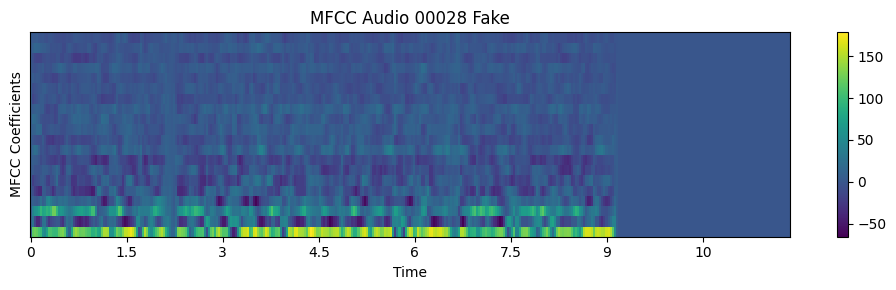

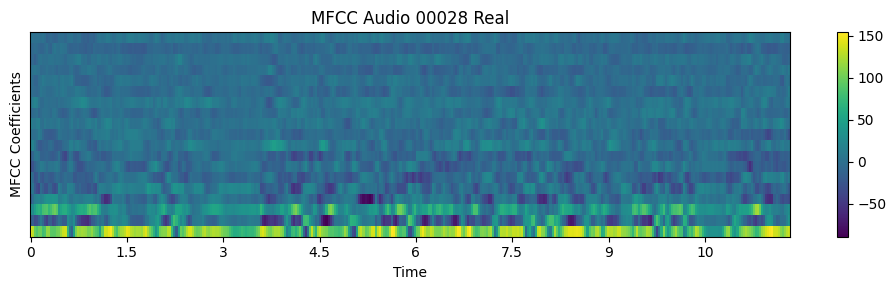

In [ ]:

# File audio fake
audio_path_fake = "/content/FakeAVCeleb_v1.2small/Fake/men/id00963/00028_fake.mp3"
#audio_path_fake = "/content/FakeAVCeleb_v1.2small/Fake/men/id00415/00017_fake.mp3"
# Parametri
frame_length = 2048
hop_length = 512

sr=16000
n_mfcc=20

y, sr = librosa.load(audio_path_fake, sr=sr)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc+1, hop_length=hop_length, n_fft=frame_length)

# Visualizza MFCC con asse x in secondi
plt.figure(figsize=(10, 3))

librosa.display.specshow(mfcc[1:], sr=sr, x_axis='time', hop_length=hop_length,cmap='viridis')
plt.colorbar()
plt.title('MFCC Audio 00028 Fake')
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()

#----------------------------
# File audio real
audio_path_real ="/content/FakeAVCeleb_v1.2small/Real/men/id00963/00028.mp3"
y, sr = librosa.load(audio_path_real, sr=sr)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length,n_fft=frame_length)

# Visualizza MFCC con asse x in secondi
plt.figure(figsize=(10, 3))

librosa.display.specshow(mfcc[1:], sr=sr, x_axis='time', hop_length=hop_length,cmap='viridis')
plt.colorbar()
plt.title('MFCC Audio 00028 Real')
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()



##Rimozione silenzi anomali con la feature Energy

***Problema***: dallo studio del dataset, abbiamo potuto notare che la maggior parte degli audio fake presentano un silenzio finale. Questo è un problema perchè c'è il rischio che il nostro modello impari a classificare gli audio solo grazie a questa pausa finale, il che sarebbe sbagliato.

***Soluzione***: utilizziamo la feature Energy per rilevare il silenzio, il rumore e il parlato. I silenzi e le pause sono importanti per distinguere gli audio real da quelli fake, e proprio per questo motivo eliminiamo solamente il silenzio presente sul finale dell'audio per evitare che il modello impari da questa caratteristica errata. Dopo aver eliminato il silenzio finale, in certi casi rimangono dei residui, sia all'inizio che alla fine dell'audio. Per evitare che il modello possa imparare da questi micro-pattern (anche se sono molto piccoli), effettuiamo un ulteriore taglio applicando una soglia più alta esclusivamente sulla testa e sulla coda dell'audio.

In particolare, utilizziamo la RMS (Root Mean Square energy).

Esempio del taglio della pausa finale di un audio, che poi verrà eseguito su tutto il dataset:

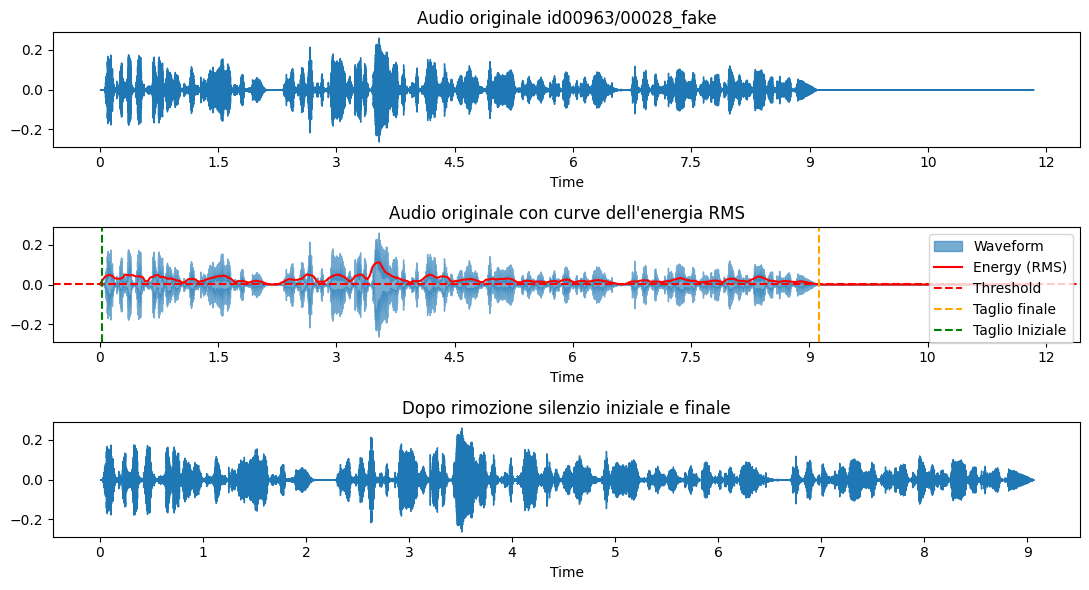

In [ ]:
# Carica audio
audio_path = "/content/FakeAVCeleb_v1.2small/Fake/men/id00963/00028_fake.mp3"
#audio_path = "/content/FakeAVCeleb_v1.2small/Fake/men/id00185/00015_fake.mp3"


# Parametri
frame_length = 2048
hop_length = 512
sr=16000
threshold=1e-3

y, sr = librosa.load(audio_path, sr=sr)


# Calcola energia RMS
rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

threshold = 1e-3
non_silent = np.where(rms > threshold)[0]

def trim_silence(y, frame_length=frame_length, hop_length=hop_length, threshold=threshold):
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    non_silent = np.where(rms > threshold)[0]

    if len(non_silent) > 0:
        last_frame = max(0, non_silent[-1])
        last_sample = librosa.frames_to_samples(last_frame + 1, hop_length=hop_length)
        y_trimmed = y[:last_sample]
        return y_trimmed, last_sample
    else:
        return np.array([]), 0


y_trimmed, last_sample = trim_silence(y)


#Tagliamo i residui di silenzio finale
def trim_energy_tail(y, sr, window_sec=0.03, energy_thresh=0.005):
    window_size = int(sr * window_sec)  # guardiamo gli ultimi 0.03s
    if len(y) < window_size:
        return y  # troppo corto per tagliare

    tail = y[-window_size:]  # coda finale
    energy = np.mean(tail ** 2)  # calcolo dell'energia della coda

    if energy < energy_thresh:  # se molto bassa
        return y[:-window_size]  # taglia via la coda
    return y

#Tagliamo i residui di silenzio iniziale
def trim_energy_head(y, sr, window_sec=0.03, energy_thresh=0.01):
    window_size = int(sr * window_sec)

    if len(y) < window_size:
        return y, 0

    head = y[:window_size]
    energy = np.mean(head ** 2)

    if energy < energy_thresh:
        return y[window_size:], window_size  # ritorna anche l'indice
    return y, 0



y_taglio_coda=trim_energy_tail(y_trimmed, sr)


# Applichiamo il trim iniziale e ottieniamo il numero di campioni tagliati
y_totale, start_sample = trim_energy_head(y_taglio_coda, sr=sr)

# Calcolo del tempo del taglio iniziale in secondi
cut_time_start = librosa.samples_to_time(start_sample, sr=sr)

# Calcolo del tempo del taglio finale (già lo fai)
cut_time_end = librosa.samples_to_time(last_sample, sr=sr)

# Calcolo per la visualizzazione
times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

# Trova il tempo del taglio finale (in secondi)
cut_time = librosa.samples_to_time(last_sample, sr=sr)

# Visualizzazione
plt.figure(figsize=(11, 6))

# Audio originale semplice
plt.subplot(3, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Audio originale id00963/00028_fake")

# Audio originale con curva RMS
plt.subplot(3, 1, 2)
librosa.display.waveshow(y, sr=sr, alpha=0.6, label="Waveform")
plt.plot(times, rms, color='red', label="Energy (RMS)")
plt.axhline(y=threshold, color='r', linestyle='--', label="Threshold")
plt.axvline(x=cut_time, color='orange', linestyle='--', label="Taglio finale")
plt.axvline(x=cut_time_start, color='green', linestyle='--', label="Taglio Iniziale")
plt.title("Audio originale con curve dell'energia RMS")
plt.legend(loc="upper right")

# Audio dopo rimozione silenzio iniziale e finale
plt.subplot(3, 1, 3)
librosa.display.waveshow(y_totale, sr=sr)
plt.title("Dopo rimozione silenzio iniziale e finale")

plt.tight_layout()
plt.show()

##Definizione dei parametri

In [ ]:
'''
Sampling rate: è la frequenza di campionamento del segnale
audio, cioè quante volte al secondo viene campionato il
segnale analogico per convertirlo in digitale.
(range consigliato: 8000-22050 HZ)
'''
SR = 16000 # @param {type:"integer"}


'''
Numero di coefficienti MFCC da estrarre per ogni frame.
Più coefficienti possono catturare più dettagli,
ma aumentano la complessità.
(range consigliato: 12-20 coefficienti)
'''
N_MFCC = 20  # @param {type:"integer"}

'''
L'hop length definisce quanto ci si sposta avanti nel segnale
da un frame al successivo.
'''
HOP_LENGTH=512 # @param {type:"integer"}


'''
Frame length definisce la dimensione della finestra di analisi.
Avere un frame_length maggiore dell'hop_length, ci permette di
avere più informazioni grazie alla sovrapposizione
'''
FRAME_LENGTH=2048 # @param {type:"integer"}

'''
Valore di soglia per togliere il silenzio finale
'''
THRESHOLD=1e-3# @param {type:"number"}

'''
Finestra da guardare per analizzare i residui
'''
WINDOW_SEC = 0.03 # @param {type:"number"}

'''
Soglia per cancellare i residui (leggermente più grande della THRESHOLD)
'''
ENERGY_THRESH= 0.005 # @param {type:"number"}



##Preprocessing dell'audio

Questa funzione si occupa della pre-elaborazione di un segnale audio per renderlo più omogeneo e privo di informazioni ridondanti prima dell'estrazione delle feature.

1. ***Caricamento del file audio***:
inizialmente carichiamo il segnale audio utilizzando librosa.load(), con un campionamento forzato alla frequenza specificata (sr). Il file viene convertito in un array di campioni mono.

2. ***Rimozione del silenzio finale***:
calcoliamo l’energia RMS (Root Mean Square) del segnale per identificare le porzioni silenziose. Se esistono frame con energia superiore a una soglia (threshold), viene individuato l’ultimo frame non silenzioso e il segnale viene troncato di conseguenza, eliminando il silenzio finale. In caso contrario, il file viene scartato perché considerato interamente silenzioso. Dopo che effettuiamo questo taglio, eliminiamo anche i residui con energy molto bassa che rimangono sulla testa e sulla coda dell'audio.

3. ***Normalizzazione del volume***:
il segnale viene poi normalizzato per avere valori di volume compresi tra [-1, 1].
Portiamo tutti gli audio allo stesso livello di riferimento, evitando che alcune clip influenzino il modello solo perché sono più forti o più deboli.
In questo modo, riduciamo la variabilità dovuta al livello di registrazione anziché al contenuto fonetico o spettrale e riduciamo eventuali distorsioni.


4. ***Restituzione del segnale preprocessato***:
il segnale audio risultante, ora normalizzato e privato di eventuale silenzio finale, viene restituito per essere successivamente utilizzato per l’estrazione di feature con MFCC.

In [ ]:
def preprocessing_audio(file_path, sr=SR, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH, threshold=THRESHOLD):

    # 1 - Caricamento audio
    y, _ = librosa.load(file_path, sr=sr)

    # 2 - Rimozione dei silenzi finali e iniziali
    # Silenzio finale
    def trim_silence(y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH, threshold=THRESHOLD):
        rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        non_silent = np.where(rms > threshold)[0]

        if len(non_silent) > 0:
            last_frame = max(0, non_silent[-1])
            last_sample = librosa.frames_to_samples(last_frame + 1, hop_length=hop_length)
            y_trimmed = y[:last_sample]
            return y_trimmed, last_sample
        else:
            return np.array([]), 0

    # Taglio dei residui dopo il taglio del silenzio finale
    def trim_energy_tail(y, sr, window_sec=WINDOW_SEC, energy_thresh=ENERGY_THRESH):
        window_size = int(sr * window_sec)
        if len(y) < window_size:
            return y
        tail = y[-window_size:]
        energy = np.mean(tail ** 2)
        if energy < energy_thresh:
            return y[:-window_size]
        return y

    # Taglio dei residui iniziali
    def trim_energy_head(y, sr, window_sec=WINDOW_SEC, energy_thresh=ENERGY_THRESH):
        window_size = int(sr * window_sec)
        if len(y) < window_size:
            return y, 0
        head = y[:window_size]
        energy = np.mean(head ** 2)
        if energy < energy_thresh:
            return y[window_size:], window_size
        return y, 0

    # Richiamiamo la funzione per la rimozione silenzio finale tramite RMS
    y_trimmed, last_sample = trim_silence(y, frame_length=frame_length, hop_length=hop_length, threshold=threshold)
    if len(y_trimmed) == 0:
        raise ValueError(f"{file_path}: Audio interamente silenzioso.")

    # Richiamiamo la funzione per la rimozione dei residui del silenzio finale
    y_tail_trimmed = trim_energy_tail(y_trimmed, sr)

    # Richiamiamo la funzione per la rimozione dei residui del silenzio iniziale
    y_totale, start_sample = trim_energy_head(y_tail_trimmed, sr)

    # 3 - Normalizzazione volume
    if np.max(np.abs(y_totale)) > 0:
        y_totale = y_totale / np.max(np.abs(y_totale))
    else:
        raise ValueError(f"{file_path}: Segnale vuoto o completamente silenzioso dopo il trimming.")


    # 4 - Segnale preprocessato
    return y_totale


##Estrazione delle features con MFCC

Questa funzione serve per estrarre caratteristiche numeriche (feature) da un file audio, che saranno poi utilizzate per l’addestramento e la valutazione del classificatore.

Trasformiamo un file .mp3 in un vettore numerico che rappresenta la sua firma acustica.

Per l'estrazione delle feature utilizziamo la media + deviazione standard per ogni set di features.

1. ***Media***: indica il valore medio di ogni coefficiente lungo tutto l’audio.
Cattura il profilo acustico globale, come il timbro medio del segnale. E' robusta al rumore e ai piccoli cambiamenti temporali.

2. ***Deviazione standard***: misura quanto varia nel tempo ogni coefficiente, catturando la dinamica del parlato o delle transizioni nel suono.
È utile per distinguere audio più monotoni (SD bassa) da quelli più espressivi o rumorosi (SD alta). E' più sensibile alla densità temporale.

Usando sia media che std, combiniamo informazione di contenuto + dinamica.

Applichiamo media e deviazione standard non solo sui coefficienti MFCC ma anche sulle derivate temporali degli MFCC:

- Delta: misura la variazione tra un frame e i suoi vicini catturando la velocità del cambiamento acustico.
- Delta-Delta: misura l’accelerazione del cambiamento fornendo un'indicazione della curvatura nel segnale vocale. Aggiunge ulteriore profondità per distinguere sfumature nel parlato.

Queste feature servono per introdurre informazioni temporali locali nelle feature.


In [ ]:
def extract_features(file_path, sr=SR, n_mfcc=N_MFCC, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH, threshold=THRESHOLD):
    y = preprocessing_audio(file_path, sr, frame_length, hop_length, threshold) # Carichiamo l'audio normalizzato

    # -------------------------------
    # ESTRAZIONE FEATURE MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length,n_fft=FRAME_LENGTH) #Estrazione dei MFCC
    delta = librosa.feature.delta(mfcc) #Rappresenta la variazione nel tempo dei MFCC (derivata prima).
    delta2 = librosa.feature.delta(mfcc, order=2) #Rappresenta la variazione della variazione (derivata seconda).

    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1),
        np.std(mfcc, axis=1),
        np.std(delta, axis=1),
        np.std(delta2, axis=1)
    ])

    return features #Vettore numerico fisso


##Caricamento del dataset

Carichiamo il dataset audio, estraiamo le feature da ciascun file .mp3 e associamo ad ognuno l'etichetta corretta.

In [ ]:
def load_dataset(root_dir):
    X = []
    y = []
    file_paths = []  # Tracciamento dei nomi dei file (utile per poi visualizzare gli errori)

    for label_name in ["Real", "Fake"]:
        label = 0 if label_name == "Real" else 1
        for gender in ["men", "women"]:
            path = os.path.join(root_dir, label_name, gender)
            for speaker_id in os.listdir(path):
                speaker_path = os.path.join(path, speaker_id)
                for filename in os.listdir(speaker_path):
                    if filename.endswith(".mp3"):
                        file_path = os.path.join(speaker_path, filename)
                        try:
                            feats = extract_features(file_path)
                            X.append(feats)
                            y.append(label)
                            file_paths.append(file_path)  # Salviamo il nome del file
                        except Exception as e:
                            print(f"Errore con {file_path}: {e}")

    return np.array(X), np.array(y), np.array(file_paths)


In [ ]:
X, y, file_names  = load_dataset("/content/FakeAVCeleb_v1.2small")

#📊 Modello shallow SVM

*(Esempio di separazione con kernel non lineare)*

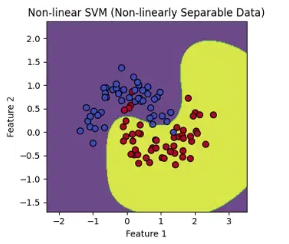

L’SVM è un classificatore supervisionato che cerca il miglior confine (iperpiano) per separare due classi nei dati. Nel nostro caso, lavora in uno spazio di 120 dimensioni, ognuna rappresentante una caratteristica dell’audio.

***Perché 120?***

Calcoliamo le statistiche "media e sd" per mfcc, delta e delta^2, utilizzando 20 coefficienti per ogni frame (120=20*6).

Poiché i dati audio non sono linearmente separabili, usiamo un kernel RBF, che proietta i dati in uno spazio trasformato dove la separazione è più semplice.

L’SVM non lavora direttamente sull’audio, ma sul vettore numerico estratto da ciascun file. La sua capacità di distinguere le classi dipende quindi fortemente dalla qualità delle feature: più riescono a rappresentare le differenze tra audio reali e fake, migliore sarà la classificazione.



---



##SVM: cross validation


Suddividiamo il dataset in 80% training set e 20% test set, in modo stratificato e riproducibile.

stratify=y: garantisce che la proporzione di classi (Real/Fake) rimanga bilanciata sia nel train che nel test.



In [ ]:
set_seed=10
# Dividiamo il dataset in train (80%) e test (20%)
X_train, X_test, y_train, y_test, files_train, files_test = train_test_split(
    X, y,file_names, test_size=0.2, stratify=y, random_state=set_seed
)




---


Ora costruiamo una pipeline che esegue due operazioni in sequenza:
standardizzazione delle feature e addestramento del modello SVM con kernel RBF.

* StandardScaler(): normalizza le feature centrandole (media = 0) e scalandole (sd = 1).
È fondamentale per SVM, poiché il modello è sensibile alla scala delle feature e garantisce che tutte le dimensioni abbiano peso comparabile.

* SVC(kernel='rbf', probability=True): utilizziamo un Support Vector Classifier con kernel='rbf', ovvero usa un kernel radiale (Radial Basis Function) che permette al modello di apprendere confini non lineari tra le classi.
probability=True serve per abilitare la stima delle probabilità di appartenenza alle classi.

In [ ]:
# Pipeline base (StandardScaler + SVC con RBF)
model = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True))



---

StratifiedKFold mantiene le proporzioni originali tra le classi (Real e Fake) in ogni fold, utile in problemi di classificazione bilanciata/sbilanciata.

La cross validation suddivide il training set in 5 fold e funziona così:
1. Il training set viene suddiviso in 5 parti (fold) di dimensioni simili.

2. Il modello viene allenato 5 volte: ogni volta su 4 fold (80%) e testato sul fold rimanente (20%, validation set).

3. Ogni fold fa da "valida" una sola volta.

4. Si calcola l’accuratezza media sui 5 round.

5. Questo processo viene applicato effettivamente all'interno di GridSearchCV e si ripete per ogni combinazione di C e gamma, valutando ogni combinazione di C e gamma usando accuracy come metrica (tuning degli iperparametri).



***A cosa servono gli iperparametri C e gamma?***
* C: regola il compromesso tra accuratezza sul training e generalizzazione. Controlla quanta tolleranza all'errore ha il modello.

* gamma: regola la "curvatura" della funzione decisionale (quanto è influenzata dai singoli punti).




Cambiando il seed, può succedere che le suddivisioni cambiano leggermente: diverse istanze finiscono in training o validation.

Questo influenza la stima della performance di ogni combinazione di iperparametri, perciò potremo ritrovarci a volte delle stime di c e gamma diverse in training con seed differenti.

***Questo cambiamento è dovuto anche alla grandezza ridotta del nostro dataset***.


In [ ]:
#Utilizzare skf permette di avere degli split bilanciati
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=set_seed)

# Griglia dei valori di C da testare
param_grid = {'svc__C': [0.001, 0.01, 0.1, 1, 10],
              'svc__gamma': [0.001, 0.01, 0.1,1, 10]}

# GridSearch con cross-validation 5-fold
grid = GridSearchCV(
    model,
    param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=1,  # usa tutti i core -1
    refit=True,
    verbose=True
)

# Esegui grid search sul training set (80%)
grid.fit(X_train, y_train)

# Stampa i risultati
# Ricordiamo che c dipende da gamma e viceversa! Troviamo la combinazione migliore tra i valori
print("Miglior valore del parametro C:", grid.best_params_['svc__C'])
print("Miglior valore del parametro gamma:", grid.best_params_['svc__gamma'])
print("Accuracy media CV migliore:", grid.best_score_)

print(grid.best_estimator_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Miglior valore del parametro C: 10
Miglior valore del parametro gamma: 0.01
Accuracy media CV migliore: 0.94375
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=10, gamma=0.01, probability=True))])


Prendiamo il modello ottimizzato con i migliori iperparametri trovati dalla GridSearchCV e effettuiamo la valutazione su test set.

In grid abbiamo refit=True, perciò non abbiamo bisogno di ri-fittare il nostro modello finale

In [ ]:
final_model = grid.best_estimator_

# Valutazione su test set
y_test_pred = final_model.predict(X_test) # predice le classi sugli esempi del test set, cioè quelli mai visti durante il training.
y_test_proba = final_model.predict_proba(X_test)[:, 1] # predice la probabilità della classe positiva

test_accuracy = accuracy_score(y_test, y_test_pred)


##SVM: metriche e plot dei risultati

Classification Report:
              precision    recall  f1-score   support

        Real       0.95      1.00      0.98        20
        Fake       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40




Final test accuracy: 0.975


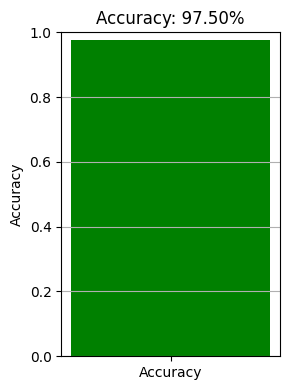




Matrice di confusione:


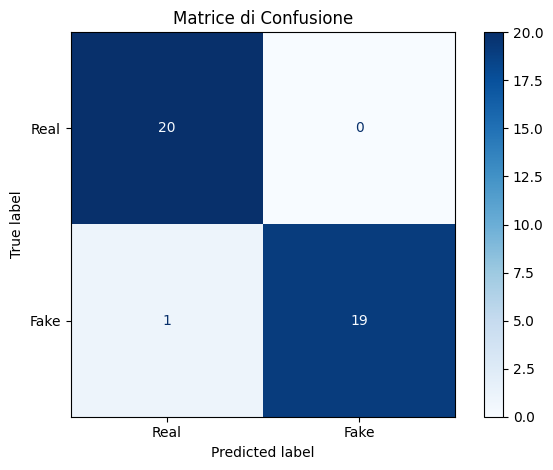




Test ROC AUC: 0.975


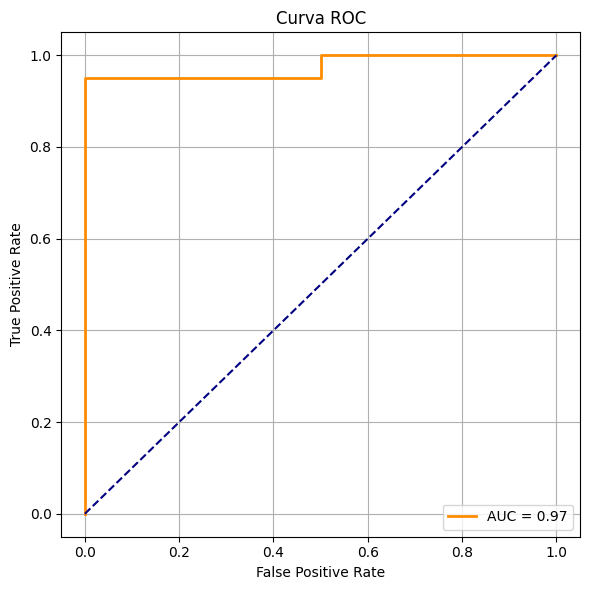

In [ ]:
#------ Classification Report
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Real", "Fake"]))
print("\n\n")


#------ Riassunto metriche
print("Final test accuracy:", test_accuracy)


#------ Bar Plot dell'accuratezza
plt.figure(figsize=(3, 4))
plt.bar(["Accuracy"], [test_accuracy], color='green')
plt.ylim(0, 1)
plt.title(f"Accuracy: {test_accuracy*100:.2f}%")
plt.ylabel("Accuracy")
plt.grid(axis='y')
plt.tight_layout()
plt.show()
print("\n\n")


#------ Matrice di confusione
print("Matrice di confusione:")
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice di Confusione")
plt.grid(False)
plt.tight_layout()
plt.show()
print("\n\n")

#------ Curva ROC + AUC
r_auc = roc_auc_score(y_test, y_test_proba)
print("Test ROC AUC:", r_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()




##SVM: visualizzazione delle classificazioni errate

Visualizziamo quali audio sono stati classificati in modo errato.


In [ ]:
# Lista degli errori
errors = [
    files_test[i] for i in range(len(y_test))
    if y_test[i] != y_test_pred[i]
]

# Stampa i nomi dei file con classificazione errata
print("Audio classificati erroneamente:")
for file_path in errors:
    print(file_path)


Audio classificati erroneamente:
/content/FakeAVCeleb_v1.2small/Fake/women/id01018/00072_fake.mp3


Visualizziamo una galleria di 12 immagini di test (forma d’onda) dove è presente almeno un errore, indicando l'etichetta vera e le
etichette predette da entrambi i classificatori. **Le forma d'onda in questione sono degli audio non ancora trasformati e normalizzati.**

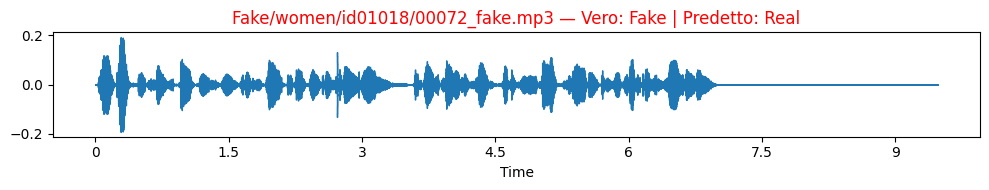

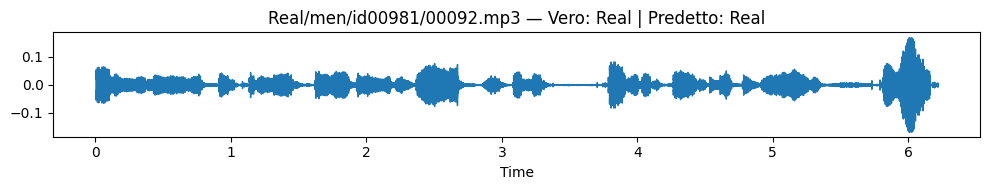

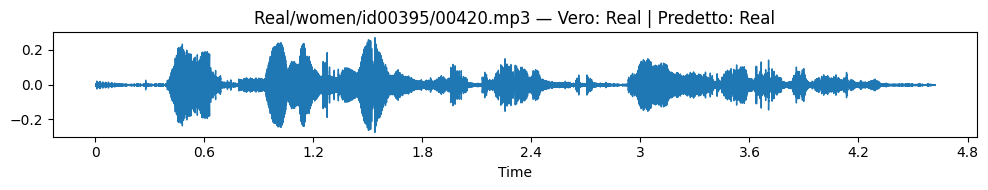

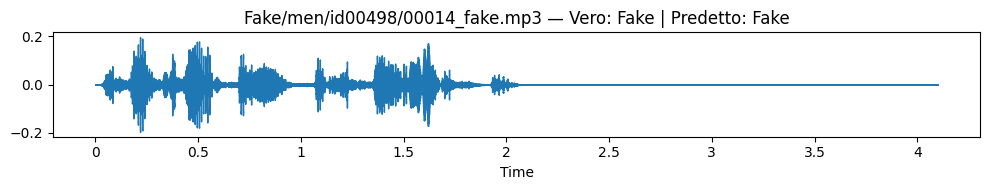

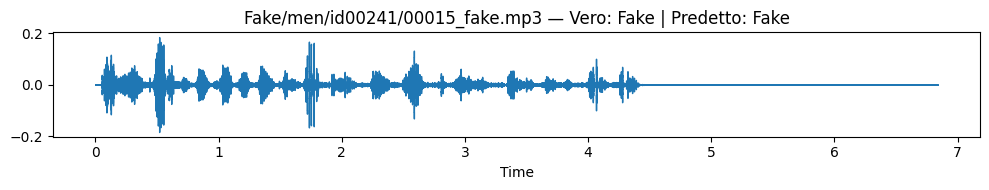

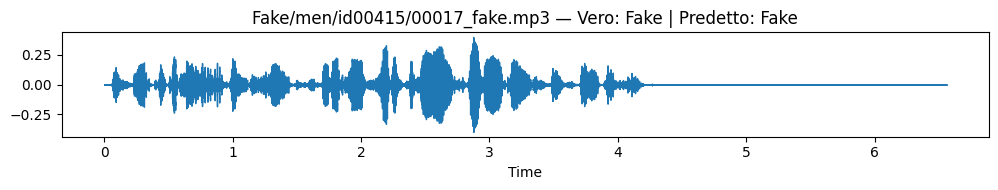

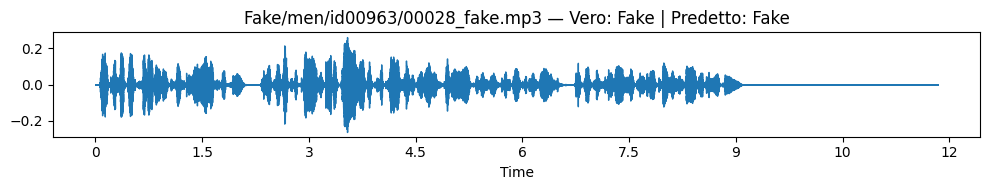

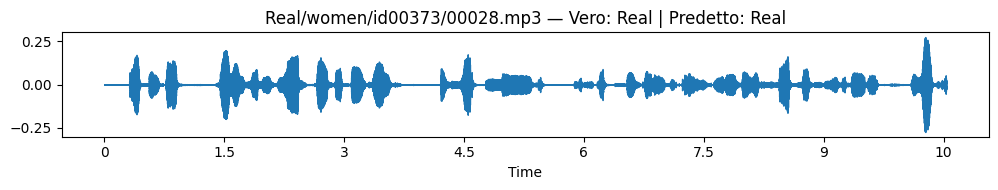

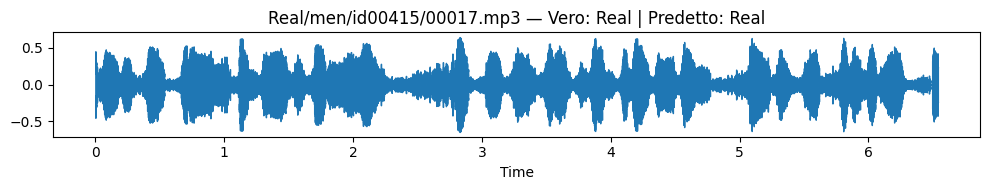

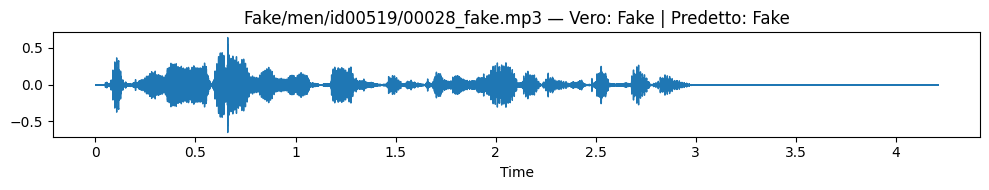

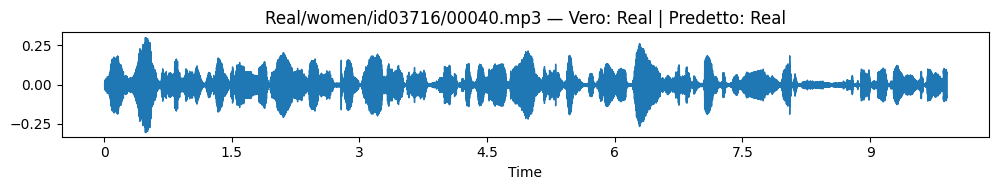

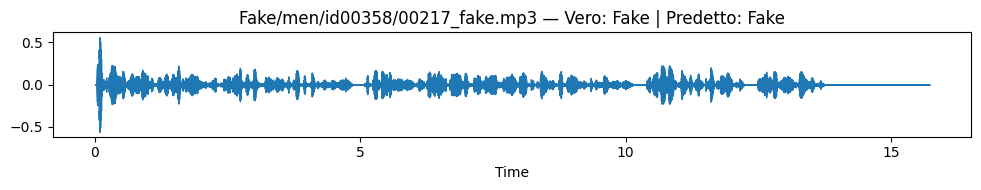

In [ ]:
# Percorso base da rimuovere nel titolo
base_path = "/content/FakeAVCeleb_v1.2small"

# Trova classificazioni errate e corrette
errors = []
corrects = []

for i in range(len(y_test)):
    if y_test[i] != y_test_pred[i]:
        errors.append((files_test[i], y_test[i], y_test_pred[i]))
    else:
        corrects.append((files_test[i], y_test[i], y_test_pred[i]))

# Numero di immagini da visualizzare
N_PLOTS = 12

# Selezioniamo tutte quelle errate e poi completiamo con alcune corrette
selected = errors[:N_PLOTS]  # massimo N_PLOTS errori
n_remaining = N_PLOTS - len(selected)

if n_remaining > 0:
    selected += corrects[:n_remaining]

# Plot
for file_path, true, pred in selected:

    y_audio, sr = librosa.load(file_path, sr=SR)

    # Plot forma d’onda
    plt.figure(figsize=(10, 2))
    librosa.display.waveshow(y_audio, sr=sr)

    # Percorso relativo (senza /content/FakeAVCeleb_v1.2small)
    relative_path = os.path.relpath(file_path, base_path)

    # Titolo con colore
    title_color = 'red' if true != pred else 'black'
    title = f"{relative_path} — Vero: {'Real' if true == 0 else 'Fake'} | Predetto: {'Real' if pred == 0 else 'Fake'}"
    plt.title(title, color=title_color)

    plt.tight_layout()
    plt.show()


Ora visualizziamo sempre le 12 immagini di test che però rappresentano le forme d'onda dopo aver subito il preprocessing

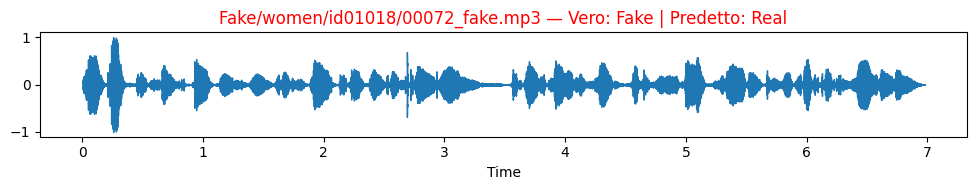

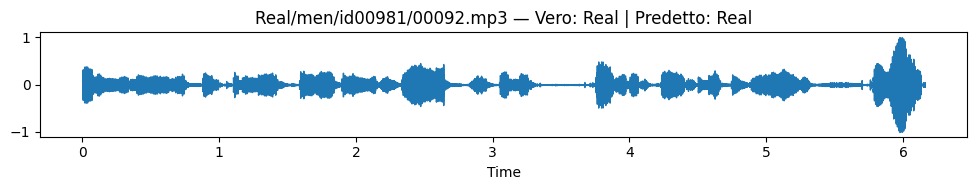

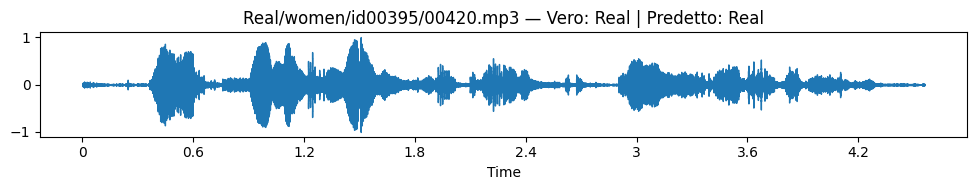

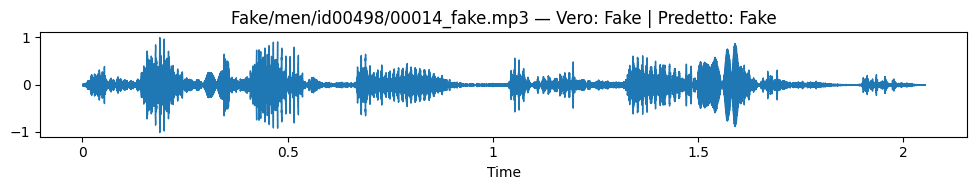

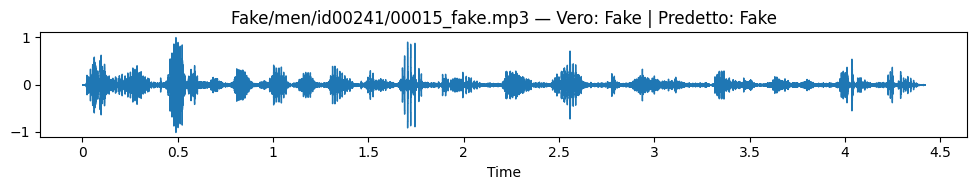

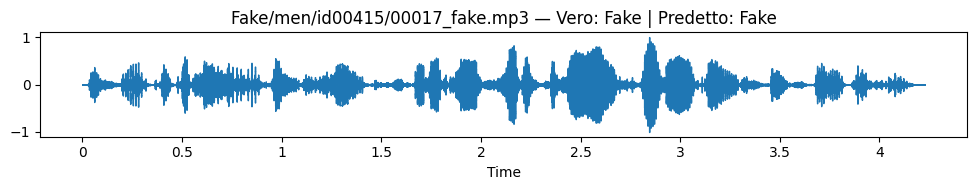

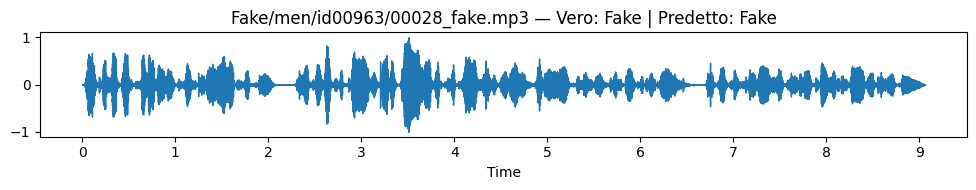

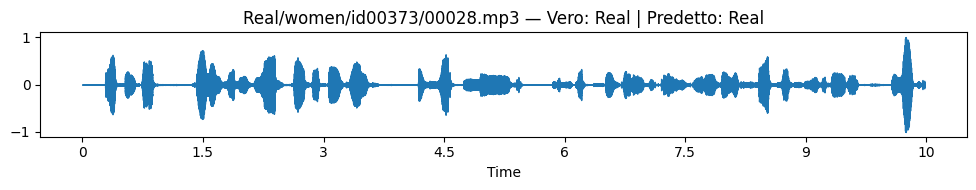

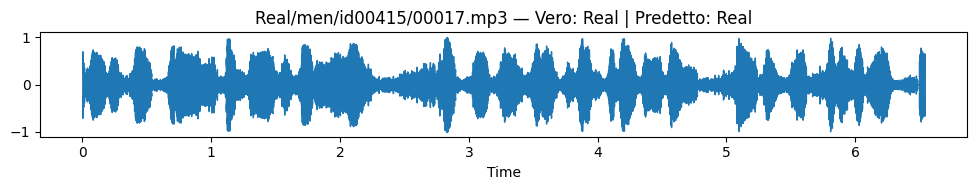

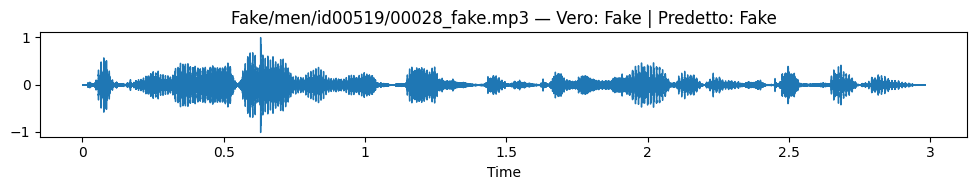

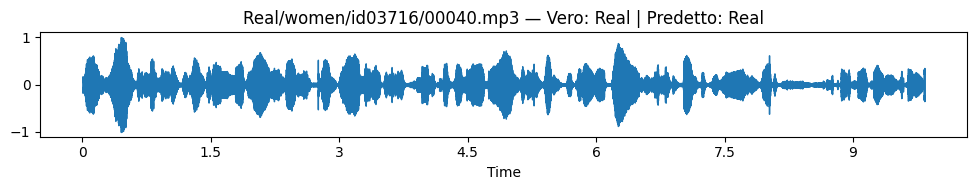

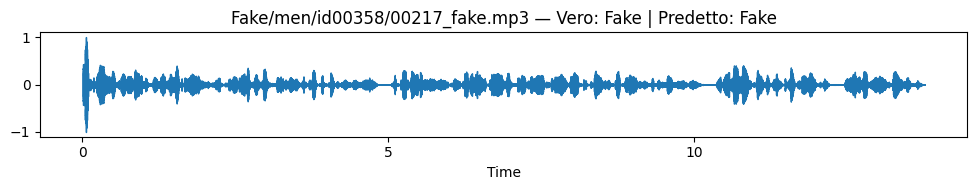

In [ ]:
# Percorso base da rimuovere nel titolo
base_path = "/content/FakeAVCeleb_v1.2small"

# Trova classificazioni errate e corrette
errors = []
corrects = []

for i in range(len(y_test)):
    if y_test[i] != y_test_pred[i]:
        errors.append((files_test[i], y_test[i], y_test_pred[i]))
    else:
        corrects.append((files_test[i], y_test[i], y_test_pred[i]))

# Numero di immagini da visualizzare
N_PLOTS = 12

# Selezioniamo tutte quelle errate e poi completiamo con alcune corrette
selected = errors[:N_PLOTS]  # massimo N_PLOTS errori
n_remaining = N_PLOTS - len(selected)

if n_remaining > 0:
    selected += corrects[:n_remaining]

# Plot
for file_path, true, pred in selected:
    y_audio = preprocessing_audio(file_path, SR, FRAME_LENGTH, HOP_LENGTH, THRESHOLD)

    # Plot forma d’onda
    plt.figure(figsize=(10, 2))
    librosa.display.waveshow(y_audio, sr=sr)

    # Percorso relativo (senza /content/FakeAVCeleb_v1.2small)
    relative_path = os.path.relpath(file_path, base_path)

    # Titolo con colore
    title_color = 'red' if true != pred else 'black'
    title = f"{relative_path} — Vero: {'Real' if true == 0 else 'Fake'} | Predetto: {'Real' if pred == 0 else 'Fake'}"
    plt.title(title, color=title_color)

    plt.tight_layout()
    plt.show()




---





---



#🎯 CONCLUSIONE: pro e contro dell'SVM utilizzando i coefficienti MFCC

✅ PRO

- E' abbastanza efficace con feature complesse e non lineari grazie anche all'utilizzo del kernel RBF.

- Funziona bene e ha una buona capacità di generalizzazione con pochi dati

- E' veloce nel fare previsioni

- Gli MFCC, essendo più compatti degli spettrogrammi MEL, sono più leggeri: a parità di prestazioni, meglio usare questi in combinazione di un modello shallow.


❌ Contro

- Risulta poco interpretabile: non fornisce una spiegazione chiara del perché una certa previsione è stata fatta. Oltre a questo, anche l'MFCC risulta poco interpretabile alla vista.

- E' sensibile alla scelta dei parametri (C, gamma), perciò è necessario il tuning perché parametri sbilanciati possono causare overfitting o underfitting.

- Risultati e robustezza dipendono fortemente dalla qualità delle feature estratte e dai parametri utilizzati per la creazione dello spettrogramma MFCC (come il numero di coefficienti presi in considerazione)

- Viene notevolmente influenzato dal valore di soglia per la rimozione del silenzio finale: un valore troppo elevato rischia di tagliare parti importanti del parlato, mentre un valore troppo basso rischia di non tagliare abbastanza silenzio, compromettendo la classificazione e imparando i pattern di silenzio finale presenti principalmente nei fake.

- In base al seed che utilizziamo, possiamo avere dei casi "sfavorevoli" in cui abbiamo un'accuratezza leggermente inferiore, sempre dovuti alla dimensione ridotta del nostro dataset



##Salvataggio audio trasformati

Salviamo le waveform e gli spettrogrammi MFCC dopo il pre-processing per visualizzare le modifiche effettuate

In [ ]:
#Solo se serve
def reset_directory(dir_path):
    # Se la cartella esiste, la rimuove completamente
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)

    # Ricrea la cartella vuota
    os.makedirs(dir_path)

reset_directory("/content/waveform_trasformati")
reset_directory("/content/MFCC_trasformati")

In [ ]:
# Cartelle di salvataggio
save_waveform_dir = "/content/waveform_trasformati"
output_mfcc_dir = "/content/MFCC_trasformati"
os.makedirs(save_waveform_dir, exist_ok=True)
os.makedirs(output_mfcc_dir, exist_ok=True)

In [ ]:
# Directory principali
root_audio = "/content/FakeAVCeleb_v1.2small"



# Funzione per salvare immagini
def salva_spettrogrammi(file_path):
    try:
        y = preprocessing_audio(file_path, SR, FRAME_LENGTH, HOP_LENGTH, THRESHOLD)
        base_name = os.path.splitext(os.path.basename(file_path))[0]

        # Percorso relativo rispetto alla root
        rel_path = os.path.relpath(file_path, root_audio)
        rel_dir = os.path.dirname(rel_path)

        # Percorsi di salvataggio (con stessa struttura)
        waveform_subdir = os.path.join(save_waveform_dir, rel_dir)
        mfcc_subdir = os.path.join(output_mfcc_dir, rel_dir)

        os.makedirs(waveform_subdir, exist_ok=True)
        os.makedirs(mfcc_subdir, exist_ok=True)

        # --- Waveform ---
        plt.figure(figsize=(10, 3))
        librosa.display.waveshow(y, sr=SR)
        plt.title(f"Waveform - {base_name}")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Ampiezza")
        plt.tight_layout()
        plt.savefig(os.path.join(waveform_subdir, f"{base_name}_waveform.png"))
        plt.close()

        # --- MFCC ---
        mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(mfcc[1:], sr=SR, x_axis='time', hop_length=HOP_LENGTH, cmap='viridis')
        plt.colorbar()
        plt.title('MFCC')
        plt.tight_layout()
        plt.savefig(os.path.join(mfcc_subdir, f"{base_name}_mfcc.png"))
        plt.close()

    except Exception as e:
        print(f"❌ Errore su {file_path}: {e}")

# Trova tutti i .mp3
all_files = glob.glob(os.path.join(root_audio, "**", "*.mp3"), recursive=True)
print(f"Totale file trovati: {len(all_files)}")

# Esegui conversione con barra di progresso
for file_path in tqdm(all_files, desc="Salvataggio waveform + MFCC", unit="file"):
    salva_spettrogrammi(file_path)

Totale file trovati: 200


Salvataggio waveform + MFCC: 100%|██████████| 200/200 [02:43<00:00,  1.22file/s]
